In [1]:
import pandas as pd
import numpy as np
import os
import mo_gymnasium as mo_gym
import gymnasium as gym
from env.user_sim import UserSimEnv
import env.simulate as sim_utils
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import utils
import process_data as dp
import mp_selection 
from morld.pi_morld import PIMORLD
from pymoo.indicators.hv import HV

import mdp_utils
import pymc as pm
import arviz as az
import pickle
from morld.mo_pi import MOPolicyIteration
import bayesian_analysis as ba
import arviz as az


%load_ext autoreload
%autoreload 2

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
Failed to read module file 'C:\Python311\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Python311

In [2]:
state_features = ['TIR', 'TIME_Q', 'GOOD']
feature_names = ['Tiredness', 'Time available', 'Usefulness Belief']

action_col = "joint_cluster"

cluster_col = 'cluster_all'
cluster_vars = ['likedness', 'usefulness', 'difficulty']
cluster_cols = [col + '_cluster' for col in cluster_vars]

reward_cols = ["r_likedness", "r_usefulness", "r_diversity", "r_expert", "r_return"]
obj_names = ["Fun", "Perceived Usefulness", "Diversity", "Expert Usefulness", "Return Willingness"]

evaluation_cols = ["time_spent", "likedness", "usefulness", "difficulty", "PAY_next", "expert_score", "diversity"]
evaluation_names = ["Time Spent", "Likedness", "Perceived Usefulness", "Difficulty", "Return Willingness", "Expert Usefulness", "Diversity"]

NUM_CATEGORIES = 4
NUM_FEATURES = len(state_features)
NUM_VALS_PER_FEATURE = [2, 2, 3]
NUM_USER_STATES = np.prod(NUM_VALS_PER_FEATURE)
NUM_CLUSTERS = 3
MAX_COUNT = 0
NUM_COUNT_STATES = (MAX_COUNT+1)**NUM_CATEGORIES
NUM_STATES = NUM_USER_STATES * NUM_COUNT_STATES 
NUM_ACTIONS = NUM_CLUSTERS * 2  # Within each cluster we either recommend a 'least favorite' coping category or a familiar one
NUM_OBJECTIVES = len(reward_cols)

### Data preparation

First we load the data and process the samples

In [3]:
data_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\data\\'
results_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\results\\'

# Load data
action_data = pd.read_csv(os.path.join(data_folder, 'challenge_info.csv'))
samples = pd.read_csv(os.path.join(data_folder, 'processed_samples.csv'))

actions_clustered, _, _ = dp.cluster_actions(action_data, cluster_vars, num_clusters=NUM_CLUSTERS)

df, initial_distribution, mapping = dp.process_samples(samples, actions_clustered, state_features, NUM_VALS_PER_FEATURE, action_col, cluster_col, MAX_COUNT, NUM_CLUSTERS)
df.head(50)

Number of samples after processing: 3111


,user_id,day_number,TIR,MOT,GOOD,TIME_Q,PAY,TIR_next,MOT_next,GOOD_next,...,r_diversity,c_idx,s_idx,sp_idx,r_difficulty,r_likedness,r_usefulness,r_return,r_expert,joint_cluster
0,1111591584,1,5,6,6,3,6,4.0,4.0,5.0,...,1,0,8,1,0.000000,0.000000,0.000000,0.714286,0.00,5
1,1111591584,2,4,4,5,4,5,6.0,2.0,5.0,...,0,0,1,7,0.545455,0.909091,1.000000,0.857143,0.66,2
2,1111591584,3,6,2,5,3,6,4.0,5.0,5.0,...,0,0,7,4,0.454545,0.818182,0.714286,0.857143,1.00,1
3,1111591584,4,4,5,5,5,6,5.0,5.0,6.0,...,1,0,4,8,0.000000,0.000000,0.000000,0.857143,0.00,5
4,1111591584,5,5,5,6,4,6,3.0,4.0,6.0,...,0,0,8,2,0.363636,0.909091,1.000000,0.857143,0.66,1
5,1111591584,16,4,4,6,3,6,3.0,3.0,6.0,...,0,0,2,2,0.545455,0.818182,0.857143,0.857143,0.66,1
6,1139851159,1,4,5,5,4,4,2.0,7.0,6.0,...,0,0,1,5,0.818182,0.909091,1.142857,0.714286,0.33,1
7,1178274181,1,2,7,5,6,7,3.0,2.0,6.0,...,0,0,4,2,0.909091,0.636364,0.285714,1.000000,0.66,1
8,1178274181,2,3,2,6,2,7,5.0,1.0,4.0,...,0,0,2,9,0.272727,0.181818,0.285714,1.000000,0.66,2
9,1178274181,3,5,1,4,5,7,3.0,6.0,4.0,...,0,0,9,3,0.909091,0.727273,0.428571,1.000000,0.33,1


In [5]:
joint_cluster_to_action = {
    0: ("D", 0),
    1: ("FU", 0),
    2: ("FUD", 0),
    3: ("D", 1),
    4: ("FU", 1),
    5: ("FUD", 1),
}

In [6]:
correlation_matrix = df[reward_cols + ['expert_score', 'completed', 'PAY_next', 'difficulty']].corr()
display(correlation_matrix)

,r_likedness,r_usefulness,r_diversity,r_expert,r_return,expert_score,completed,PAY_next,difficulty
r_likedness,1.000000,0.919396,-0.509292,0.745545,0.122269,-0.136773,0.869225,0.122269,0.582907
r_usefulness,0.919396,1.000000,-0.501669,0.764523,0.158002,-0.089338,0.860218,0.158002,0.616551
r_diversity,-0.509292,-0.501669,1.000000,-0.516695,-0.067778,0.022273,-0.571121,-0.067778,-0.386900
r_expert,0.745545,0.764523,-0.516695,1.000000,0.086807,0.284715,0.879623,0.086807,0.642335
r_return,0.122269,0.158002,-0.067778,0.086807,1.000000,0.014946,0.074896,1.000000,0.058241
expert_score,-0.136773,-0.089338,0.022273,0.284715,0.014946,1.000000,-0.119592,0.014946,0.003876
completed,0.869225,0.860218,-0.571121,0.879623,0.074896,-0.119592,1.000000,0.074896,0.674469
PAY_next,0.122269,0.158002,-0.067778,0.086807,1.000000,0.014946,0.074896,1.000000,0.058241
difficulty,0.582907,0.616551,-0.386900,0.642335,0.058241,0.003876,0.674469,0.058241,1.000000


<Axes: >

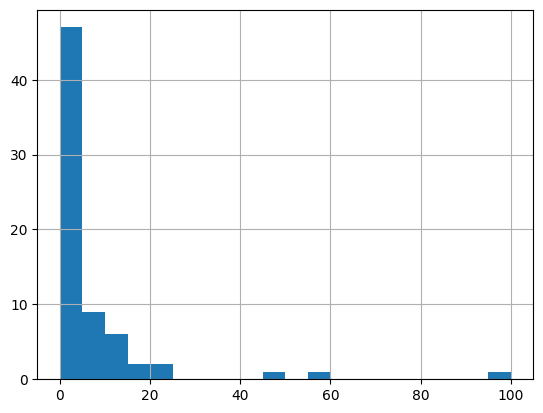

In [7]:
df.groupby(["s_idx", action_col])["time_spent"].last().hist(bins=20)

In [8]:
completed_measures = ["Likedness", "Time Spent", "Difficulty", "Expert Usefulness", "Perceived Usefulness"]
completed_df = df[df['completed'] == 1]

#### Estimate transition and reward functions

In [9]:
P_comp = mdp_utils.compute_completion_probabilities(df, NUM_USER_STATES, NUM_ACTIONS, action_col)
R = mdp_utils.compute_rewards(df, P_comp, NUM_USER_STATES, NUM_COUNT_STATES, NUM_ACTIONS, NUM_OBJECTIVES, reward_cols, action_col, mapping)
P = mdp_utils.compute_transition_probabilities(df, NUM_USER_STATES, NUM_ACTIONS, action_col)
P_return = mdp_utils.compute_return_probabilities(df)

print("P shape:", P.shape)  # Should be (nU, nA, nU)
print("R shape:", R.shape)  # Should be (nU, nC, nA, nO)
print("P_return shape:", P_return.shape)  # Should be (nU,)

P shape: (12, 6, 12)
R shape: (12, 1, 6, 5)
P_return shape: (12,)


For our simulations, we use reward distributions. 

In [10]:
df = df.merge(actions_clustered[['challenge_id'] + cluster_cols + ['time_spent_cluster']], on='challenge_id', how='left')
lam = 1  # Laplaca smoothing

# Use overall clusters or specific reward clusters?
R_probs_diff = mdp_utils.compute_reward_probabilities(completed_df, 'difficulty', NUM_USER_STATES, NUM_ACTIONS, action_col, lam=lam)
R_probs_fun = mdp_utils.compute_reward_probabilities(completed_df, 'likedness', NUM_USER_STATES, NUM_ACTIONS, action_col, lam=lam)
R_probs_pu = mdp_utils.compute_reward_probabilities(completed_df, 'usefulness', NUM_USER_STATES, NUM_ACTIONS, action_col, lam=lam)
R_probs_time = mdp_utils.compute_reward_probabilities(completed_df, 'time_spent', NUM_USER_STATES, NUM_ACTIONS, action_col, lam=lam)
R_probs_return = mdp_utils.compute_reward_probabilities(df, 'PAY_next', NUM_USER_STATES, NUM_ACTIONS, action_col, lam=lam)

R_probs = {'difficulty': R_probs_diff, 'likedness': R_probs_fun, 'usefulness': R_probs_pu, 'time_spent': R_probs_time, 'PAY_next': R_probs_return}

We need some information on the challenges for our simulation environment

In [11]:
action_categories = actions_clustered['category_id'].values  # cluster ID for each action (is same as action number if actions are clusters)
challenges_per_cluster = [[i for i in range(len(actions_clustered)) if actions_clustered[cluster_col].iloc[i] == cluster_id] for cluster_id in range(NUM_CLUSTERS)]

challenge_info = actions_clustered.set_index('challenge_id').to_dict('records')

expert_score_cols = ['score_acceptance', 'score_distraction', 'score_problem_solving', 'score_social_support']
expert_score_matrix = actions_clustered['expert_score'].values

In [12]:
env = mo_gym.make('user_env', num_actions=NUM_ACTIONS, 
                 num_objectives = NUM_OBJECTIVES, 
                 num_vals_per_feature=NUM_VALS_PER_FEATURE,
                 challenge_info=challenge_info, 
                 expert_ratings=expert_score_matrix,
                 challenges_per_cluster=challenges_per_cluster,
                 num_clusters=4,
                 transition_probs=P, 
                 completion_probs=P_comp,
                 reward_matrix=R, 
                 reward_probs=R_probs,
                 action_categories=action_categories,
                 initial_distribution=initial_distribution,
                 max_count=MAX_COUNT,
                 mapping=mapping)

### Setup Policy Iteration MORL/D algorithm

In [13]:
pop_size = 128
weights_init = "combined"
scalarization = "linear"
max_eval_iters = 500
num_iterations = 5
gamma = 0.0
ref_point = np.array([0.5, 0.5, 0.5, 0.5, 0.5])  # Reference point for Chebyshev scalarization

model_name = f'pimorld_P={pop_size}_T={num_iterations}_nO={NUM_OBJECTIVES}_gamma={gamma}'
filename = model_name
model_file = os.path.join(results_folder, model_name, filename)

# Initialize the PIMORLD algorithm
pi_morld = PIMORLD(env.unwrapped,
                   pop_size=pop_size, 
                   gamma=gamma,
                   max_eval_iters=max_eval_iters,
                   weights_init=weights_init,
                   scalarization=scalarization,
                   ref_point=ref_point)

# Train the model
pi_morld.train(num_iterations=1000, max_resets=30)

Initial weights for agents:
[[0.         0.         0.         0.         1.        ]
 [0.         0.         0.         0.20348524 0.79651476]
 [0.         0.         0.         0.40281049 0.59718951]
 [0.         0.         0.         0.60108623 0.39891377]
 [0.         0.         0.         0.79960042 0.20039958]
 [0.         0.         0.         1.         0.        ]
 [0.         0.         0.25916169 0.50793705 0.23290126]
 [0.         0.         0.25991581 0.         0.74008419]
 [0.         0.         0.26397129 0.25308243 0.48294628]
 [0.         0.         0.49094124 0.50905876 0.        ]
 [0.         0.         0.49559295 0.25665379 0.24775326]
 [0.         0.         0.50599475 0.         0.49400525]
 [0.         0.         0.74025807 0.25974193 0.        ]
 [0.         0.         0.74849568 0.         0.25150432]
 [0.         0.         1.         0.         0.        ]
 [0.         0.2487372  0.49492772 0.         0.25633508]
 [0.         0.25373475 0.24844609 0.       

In [14]:
save_path = os.path.join(results_folder, model_name, 'model')
save_file = "pimorld_trained.pkl"
save_to = os.path.join(save_path, save_file)
if not os.path.exists(save_path):
    os.makedirs(save_path)

with open(save_to, 'wb') as f:
    pickle.dump(pi_morld, f)

Inspect the discovered approximation set

In [15]:
print("Hypervolume of Pareto Archive: ", pi_morld.get_hv())
print("Number of solutions in Pareto Archive: ", len(pi_morld.pareto_archive.evaluations))

Hypervolume of Pareto Archive:  0.0798517702489602
Number of solutions in Pareto Archive:  146


In [16]:
mp_selection.get_max_unique_actions(pi_morld.pareto_archive.individuals, NUM_STATES)

{'max_unique_actions': 6,
 'avg_unique_actions': 4.333333333333333,
 'most_disputed_state': 1}

### Run simulations

In [17]:
NUM_USERS = 1000
NUM_TIMESTEPS = 28
random_within_cluster = False

In [18]:
weight_samples = np.random.dirichlet(np.ones(NUM_OBJECTIVES), size=1000)

policy_evals = np.array(pi_morld.pareto_archive.evaluations)
eum = mp_selection.calculate_expected_utility(policy_evals, weight_samples)
print("Expected Utility of Pareto Archive: ", eum)

selected_indices = mp_selection.select_policies(pi_morld.pareto_archive.individuals, policy_evals, mp_selection.score_eum, max_actions=3, weight_samples=weight_samples)
print(f"Best subset of policies has EUM: {mp_selection.calculate_expected_utility(policy_evals[selected_indices], weight_samples)}")
print("Selected policies indices: ", selected_indices)
top_n_individuals = np.array(pi_morld.pareto_archive.individuals)[selected_indices]
top_n_evaluations = np.array(pi_morld.pareto_archive.evaluations)[selected_indices]
selected_policies = np.array([ind['policy'] for ind in top_n_individuals])

selected_indices_expert = mp_selection.select_policies(pi_morld.pareto_archive.individuals, policy_evals, mp_selection.score_weighted_sum, max_actions=3, weights=[0, 0, 1, 1, 1])
print(f"Best subset of policies based on expert objectives has EUM: {mp_selection.calculate_expected_utility(policy_evals[selected_indices_expert], weight_samples)}")
print("Selected policies indices with expert objectives: ", selected_indices_expert)
selected_policies_expert = np.array([ind['policy'] for ind in np.array(pi_morld.pareto_archive.individuals)[selected_indices_expert]])
selected_evaluations_expert = np.array(pi_morld.pareto_archive.evaluations)[selected_indices_expert]

print("overlapping indices", set(selected_indices).intersection(set(selected_indices_expert)))

Expected Utility of Pareto Archive:  0.5961114098261322
Best subset of policies has EUM: 0.595549526123202
Selected policies indices:  [33, 13, 20, 21, 28, 26, 44, 14, 19, 24, 53, 16, 41, 78, 30, 43, 45, 42, 27, 9, 47, 58, 136, 121, 106, 56, 145, 17, 52, 90, 131, 29, 102, 65, 25, 124, 109, 129, 92, 126, 35, 23, 22, 46, 85, 83, 15, 133, 61, 40, 135, 95, 137, 119, 67, 91, 96, 87, 107, 99, 94, 132]
Best subset of policies based on expert objectives has EUM: 0.48867126050490356
Selected policies indices with expert objectives:  [10, 8, 113, 114, 88, 106, 110, 39, 44, 12, 11, 60, 48, 9, 98, 13, 66, 100, 89, 120, 7, 65, 103, 0]
overlapping indices {65, 9, 106, 44, 13}


In [19]:
best_expert_idx = np.argmax(np.sum(policy_evals[:, 2:], axis=1)) 
best_expert_policy = pi_morld.pareto_archive.individuals[best_expert_idx]['policy']
print("Best expert-driven policy index: ", best_expert_idx)
print("Best expert-driven policy evaluation: ", policy_evals[best_expert_idx])
print(best_expert_policy)

Best expert-driven policy index:  10
Best expert-driven policy evaluation:  [0.19480515 0.19515444 1.         0.20651787 0.6484152 ]
[4 5 5 4 5 4 4 5 4 4 3 5]


In [20]:
policy_morl_raw = mp_selection.get_actions_per_state(top_n_individuals, NUM_STATES)

policy_morl = [
    {joint_cluster_to_action[action] for action in policy_morl_raw[state]}
    for state in range(NUM_STATES)
]

print(policy_morl)

[{('FU', 0), ('FU', 1)}, {('FU', 0), ('FU', 1), ('FUD', 0)}, {('FUD', 1), ('FU', 0), ('FUD', 0)}, {('FU', 0), ('FU', 1), ('FUD', 0)}, {('FUD', 1), ('FU', 1), ('FUD', 0)}, {('FUD', 1), ('FU', 0), ('FUD', 0)}, {('FU', 0), ('FU', 1), ('FUD', 0)}, {('FUD', 1), ('FU', 0)}, {('FU', 0), ('FU', 1), ('FUD', 0)}, {('FUD', 1), ('D', 0), ('FU', 0)}, {('FU', 0), ('D', 1), ('FUD', 0)}, {('FUD', 1), ('D', 1), ('FUD', 0)}]


In [21]:
save_path = results_folder + model_name + '/simulations/'
save_path = os.path.join(results_folder, model_name, 'simulations')
save = False

In [22]:
# Simulate baseline policies
baseline_policies = []
simulation_random = sim_utils.simulate(env, NUM_USERS)
baseline_policies.append(simulation_random)

# Equal weights for all objectives
equal_weights = np.ones(NUM_OBJECTIVES) / NUM_OBJECTIVES
solver_equal = MOPolicyIteration(P, R, P_comp, equal_weights, gamma=gamma, scalarization=scalarization, max_count=MAX_COUNT, action_to_cluster=action_categories)
solver_equal.train()
policy_equal = solver_equal.policy_table
simulation_equal = sim_utils.simulate(env, NUM_USERS, policy=policy_equal, policy_name="Equal Weights Policy", random_within_cluster=random_within_cluster)
baseline_policies.append(simulation_equal)

# Weights based on correlations with completion
correlations = df[reward_cols + ['completed']].corr()['completed'][:-1]
weights_correlations = np.array(correlations) / np.sum(correlations)
print("Weights based on correlations: ", weights_correlations)
solver_corr = MOPolicyIteration(P, R, P_comp, weights_correlations, gamma=gamma, scalarization=scalarization, max_count=MAX_COUNT, action_to_cluster=action_categories)
solver_corr.train()
policy_corr = solver_corr.policy_table
simulation_corr = sim_utils.simulate(env, NUM_USERS, policy=policy_corr, policy_name="Correlation-based Policy", random_within_cluster=random_within_cluster)
baseline_policies.append(simulation_corr)

Weights based on correlations:  [ 0.41140115  0.4071381  -0.27030942  0.41632226  0.0354479 ]


In [23]:
print([joint_cluster_to_action[action] for action in policy_equal])
print([joint_cluster_to_action[action] for action in policy_corr])

[('FU', 0), ('FU', 0), ('FU', 0), ('FU', 0), ('FUD', 0), ('FUD', 0), ('FU', 0), ('FU', 0), ('FU', 1), ('FU', 0), ('D', 1), ('FUD', 0)]
[('FU', 0), ('FU', 0), ('FU', 0), ('FU', 0), ('FUD', 0), ('FUD', 0), ('FU', 0), ('FU', 0), ('FUD', 0), ('FU', 0), ('FUD', 0), ('FUD', 0)]


In [24]:
pi_morld.add_to_pareto_archive(solver_corr)
print(len(pi_morld.pareto_archive.individuals))

Policy already in archive, skipping addition.
146


#### Simulate choices between multiple optimal policies

In [25]:
choice_policies = []
# multi_policy_simulation_results_fun = sim_utils.simulate_multiple_policies(env, NUM_USERS, selected_policies, top_n_evaluations, selection='max_fun', random_within_cluster=random_within_cluster)
# all_sim_results.append(multi_policy_simulation_results_fun)
# choice_policies.append(multi_policy_simulation_results_fun)

# multi_policy_simulation_results_time = sim_utils.simulate_multiple_policies(env, NUM_USERS, selected_policies, top_n_evaluations, selection='max_usefulness', random_within_cluster=random_within_cluster)
# all_sim_results.append(multi_policy_simulation_results_time)
# choice_policies.append(multi_policy_simulation_results_time)

multi_policy_simulation_results_random = sim_utils.simulate_multiple_policies(env, NUM_USERS, selected_policies, top_n_evaluations, selection='random')
choice_policies.append(multi_policy_simulation_results_random)

multi_policy_simulation_results_expert = sim_utils.simulate(env, NUM_USERS, best_expert_policy, "MORL-EP")
choice_policies.append(multi_policy_simulation_results_expert)

multi_policy_simulation_results_combined = sim_utils.simulate_multiple_policies(env, NUM_USERS, selected_policies, top_n_evaluations, selection='combined')
choice_policies.append(multi_policy_simulation_results_combined)

In [26]:
combined_df = pd.concat(baseline_policies + choice_policies, ignore_index=True)
sim_utils.interactive_plot_objective(combined_df, evaluation_names)

interactive(children=(Dropdown(description='Objective:', options=(('Time Spent', 0), ('Likedness', 1), ('Perce…

### Analyze and visualize simulations

In [27]:
# save simulation results
if True:
    save_path = os.path.join(results_folder, model_name, 'simulations')
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    combined_df.to_pickle(os.path.join(save_path, 'combined_simulation_results.pkl'))

In [28]:
combined_df.columns

Index(['user', 't', 'action', 'challenge_id', 'state', 'next_state',
       'completed', 'counts', 'num_completed', 'counts_per_category',
       'expert_competencies', 'rewards', 'policy'],
      dtype='str')

#### Inspect adherence

In [29]:
means = []
stds = []
sems = []
for idx, sim_res in enumerate(baseline_policies + choice_policies):
    num_completed = np.stack(sim_res['num_completed']).reshape(NUM_USERS, NUM_TIMESTEPS)[:, -1]
    adherence_per_user = num_completed / NUM_TIMESTEPS
    grand_mean = np.mean(adherence_per_user)
    min = NUM_USERS
    sem = stats.sem(adherence_per_user)
    ci = stats.t.interval(0.95, df=min-1, loc=grand_mean, scale=sem)
    means.append(grand_mean)
    stds.append(np.std(adherence_per_user))
    sems.append(sem)
    print(f"{sim_res['policy'].iloc[0]:<15} | Adherence: {grand_mean:.4f} | 95% CI: ({ci[0]:.4f}, {ci[1]:.4f})")

Random          | Adherence: 0.5006 | 95% CI: (0.4947, 0.5065)
Equal Weights Policy | Adherence: 0.8647 | 95% CI: (0.8606, 0.8689)
Correlation-based Policy | Adherence: 0.8841 | 95% CI: (0.8802, 0.8880)
Multipolicy random | Adherence: 0.7884 | 95% CI: (0.7835, 0.7932)
MORL-EP         | Adherence: 0.2984 | 95% CI: (0.2929, 0.3038)
Multipolicy combined | Adherence: 0.5751 | 95% CI: (0.5701, 0.5802)


<Axes: xlabel='Timesteps', ylabel='Mean # Completed Challenges'>

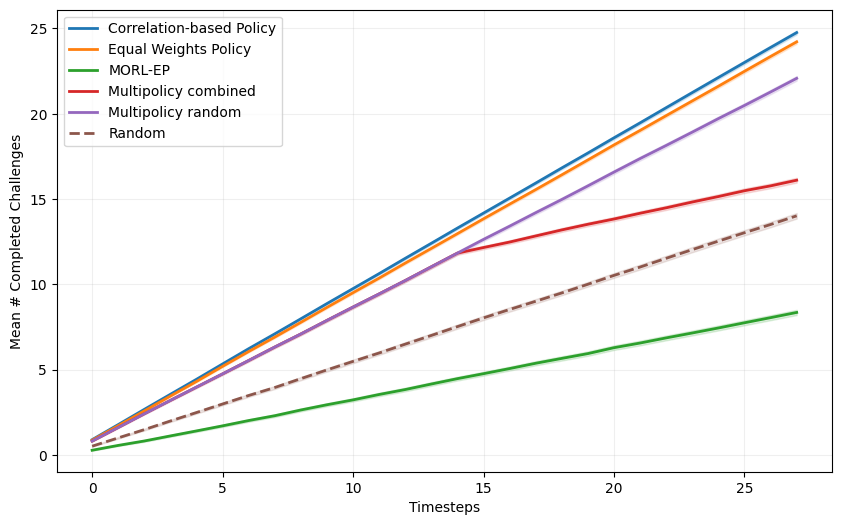

In [30]:
sim_utils.plot_simulation(combined_df, 'num_completed')

#### Inspect number of users per state

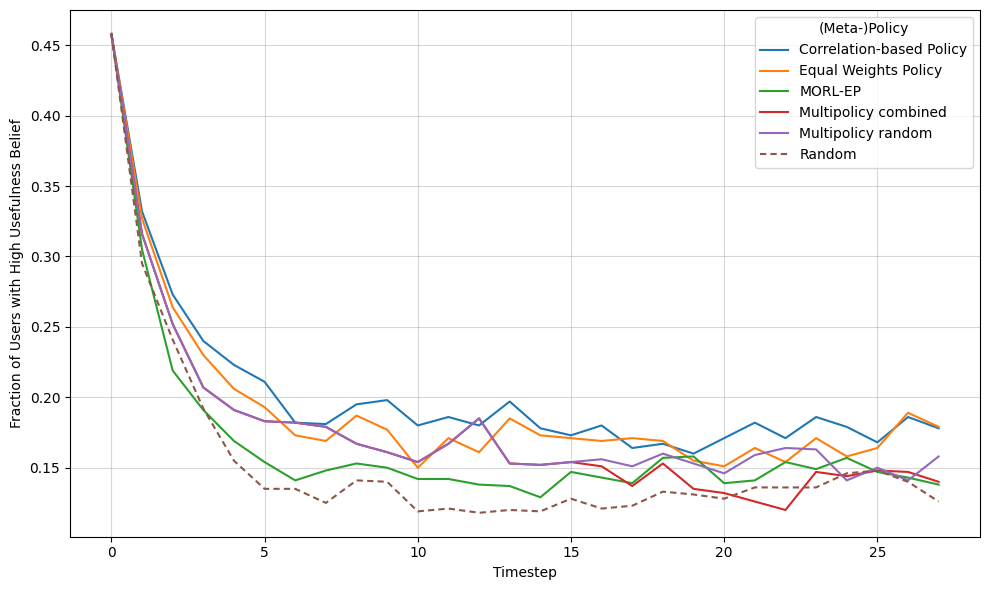

In [31]:
sim_utils.plot_state_trajectory(combined_df)

#### Inspect diversity

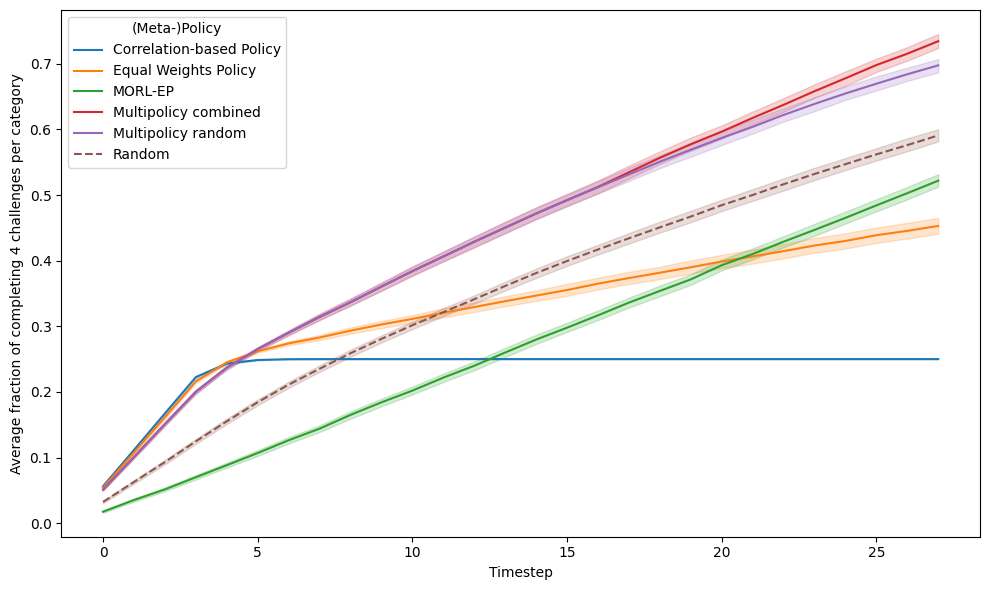

In [32]:
sim_utils.plot_fraction_completed(combined_df, 4)

#### Analyze dropout / retention

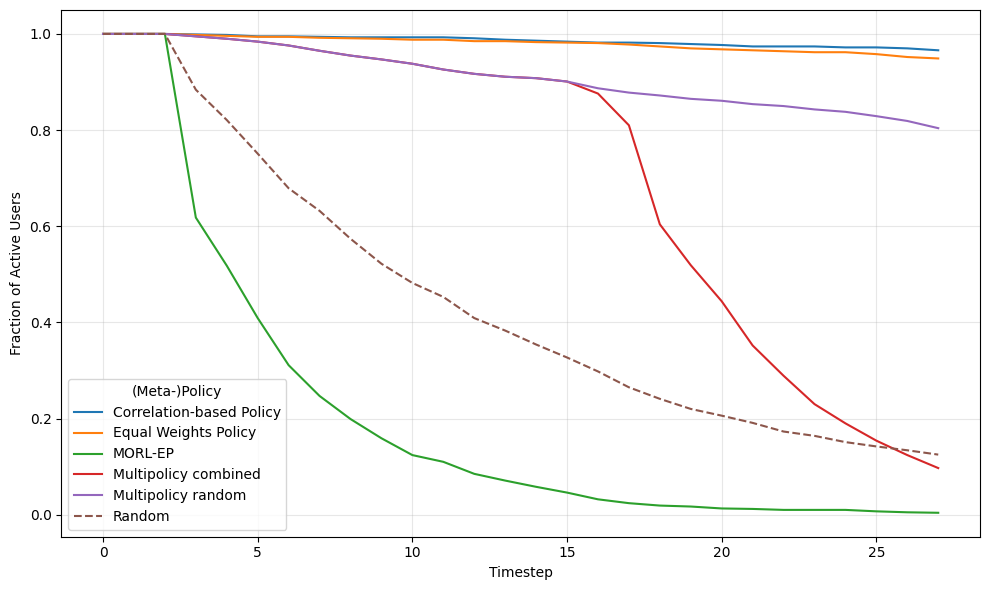

In [33]:
sim_utils.plot_dropout(combined_df)